
Loaded TXeast
  shorelines: 856
  baseline:   3

Loaded TXwest
  shorelines: 194
  baseline:   2


C:\Users\csherwood\AppData\Local\miniforge3\envs\CRS\lib\site-packages\pyogrio\raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured LineString' is converted to 'LineString'
  return ogr_read(


Saved: F:\crs\proj\2026_shoreline_analysis\usgs_dsas\output\TX_combined_shorelines_geo
Saved: F:\crs\proj\2026_shoreline_analysis\usgs_dsas\output\TX_combined_shorelines_albers
Saved: F:\crs\proj\2026_shoreline_analysis\usgs_dsas\output\TX_combined_baseline_geo
Saved: F:\crs\proj\2026_shoreline_analysis\usgs_dsas\output\TX_combined_baseline_albers


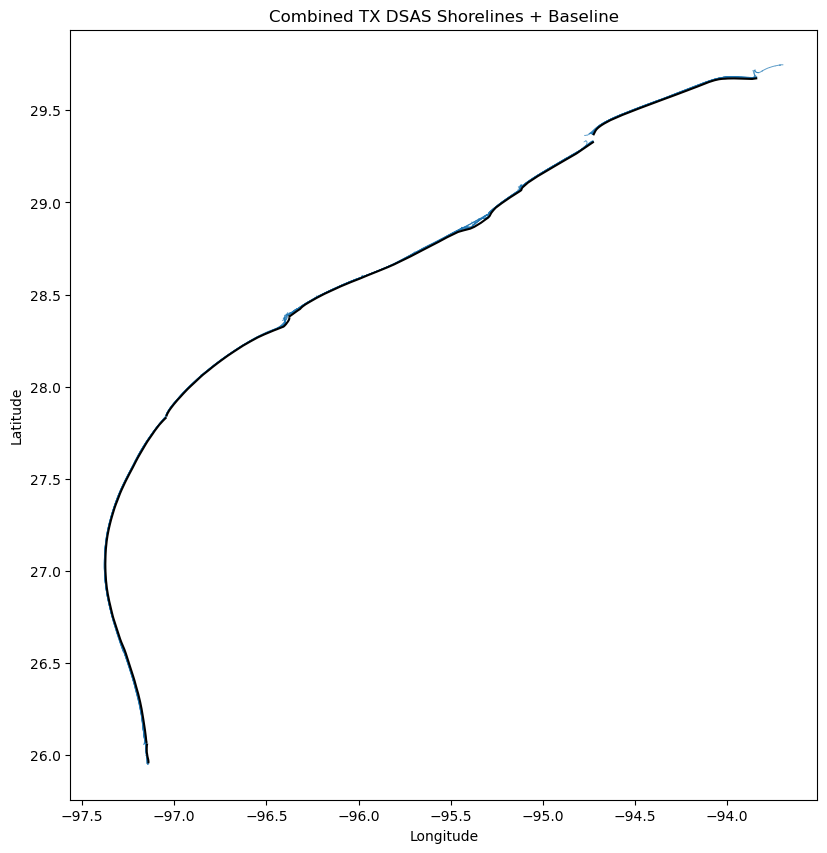

In [5]:
#!/usr/bin/env python
"""
Read and combine USGS DSAS shoreline and baseline shapefiles from zipped archives.

Hard-coded paths:
    IN_DIR  = F:/crs/proj/2026_shoreline_analysis/usgs_dsas/
    OUT_DIR = F:/crs/proj/2026_shoreline_analysis/usgs_dsas/output/

Outputs:
    - Combined GeoPackages (geo + Albers)
    - CSV tables with WKT geometry
    - QA plot
"""

from pathlib import Path
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------
# HARD-CODED PATHS
# ---------------------------------------------------------------------
IN_DIR = Path("F:/crs/proj/2026_shoreline_analysis/usgs_dsas/")
OUT_DIR = IN_DIR / "output"


# ---------------------------------------------------------------------
# CRS SETTINGS
# ---------------------------------------------------------------------
GEOGRAPHIC_CRS = "EPSG:4326"
PROJECTED_CRS = "EPSG:3083"   # Texas Albers


# ---------------------------------------------------------------------
# HELPERS
# ---------------------------------------------------------------------
def read_zipped_shapefile(zip_path):
    gdf = gpd.read_file(f"zip://{zip_path}")
    if gdf.empty:
        raise ValueError(f"No features in {zip_path}")
    return gdf


def guess_date_column(columns):
    cols_lower = {c.lower(): c for c in columns}

    candidates = [
        "date_", "date", "dates_", "shore_date",
        "shor_date", "surv_date", "timestamp", "time"
    ]

    for c in candidates:
        if c in cols_lower:
            return cols_lower[c]

    for c in columns:
        if "date" in c.lower():
            return c

    return None


def add_standard_fields(gdf, region, layer_name):
    out = gdf.copy()

    out["region"] = region
    out["layer_name"] = layer_name
    out["source_crs"] = str(out.crs)

    date_col = guess_date_column(out.columns)
    out["date_col"] = date_col if date_col else ""

    if date_col:
        out["time"] = pd.to_datetime(out[date_col], errors="coerce")
    else:
        out["time"] = pd.NaT

    return out


def reproject_two_versions(gdf):
    gdf_geo = gdf.to_crs(GEOGRAPHIC_CRS)
    gdf_proj = gdf.to_crs(PROJECTED_CRS)
    return gdf_geo, gdf_proj


def combine_layers(gdf1, gdf2):
    out = pd.concat([gdf1, gdf2], ignore_index=True)
    return gpd.GeoDataFrame(out, geometry="geometry", crs=gdf1.crs)


def add_wkt(df):
    out = df.copy()
    out["geometry_wkt"] = out.geometry.to_wkt()
    return out.drop(columns="geometry")


def make_unique_columns(df):
    """
    Ensure column names are unique (case-insensitive safe).
    """
    cols = list(df.columns)
    seen = {}
    new_cols = []

    for c in cols:
        c_low = c.lower()

        if c_low not in seen:
            seen[c_low] = 0
            new_cols.append(c)
        else:
            seen[c_low] += 1
            new_cols.append(f"{c}_{seen[c_low]}")

    df.columns = new_cols
    return df


def save_outputs(gdf, out_base):
    out_base.parent.mkdir(parents=True, exist_ok=True)

    # 🔴 FIX: ensure unique column names
    gdf_clean = make_unique_columns(gdf.copy())

    # also drop columns that are completely empty (optional but helpful)
    gdf_clean = gdf_clean.dropna(axis=1, how="all")

    # save
    gdf_clean.to_file(out_base.with_suffix(".gpkg"), driver="GPKG")
    add_wkt(gdf_clean).to_csv(out_base.with_suffix(".csv"), index=False)

    print(f"Saved: {out_base}")

# ---------------------------------------------------------------------
# LOAD FUNCTION
# ---------------------------------------------------------------------
def load_dsas(prefix):
    shore = read_zipped_shapefile(IN_DIR / f"{prefix}_shorelines.zip")
    base = read_zipped_shapefile(IN_DIR / f"{prefix}_baseline.zip")

    shore = add_standard_fields(shore, prefix, "shorelines")
    base = add_standard_fields(base, prefix, "baseline")

    print(f"\nLoaded {prefix}")
    print(f"  shorelines: {len(shore)}")
    print(f"  baseline:   {len(base)}")

    return shore, base


# ---------------------------------------------------------------------
# MAIN
# ---------------------------------------------------------------------
def main():

    OUT_DIR.mkdir(parents=True, exist_ok=True)

    # Load east/west
    shore_e, base_e = load_dsas("TXeast")
    shore_w, base_w = load_dsas("TXwest")

    # Reproject
    shore_e_geo, shore_e_proj = reproject_two_versions(shore_e)
    shore_w_geo, shore_w_proj = reproject_two_versions(shore_w)

    base_e_geo, base_e_proj = reproject_two_versions(base_e)
    base_w_geo, base_w_proj = reproject_two_versions(base_w)

    # Combine
    shore_geo = combine_layers(shore_e_geo, shore_w_geo)
    shore_proj = combine_layers(shore_e_proj, shore_w_proj)

    base_geo = combine_layers(base_e_geo, base_w_geo)
    base_proj = combine_layers(base_e_proj, base_w_proj)

    # Save
    save_outputs(shore_geo, OUT_DIR / "TX_combined_shorelines_geo")
    save_outputs(shore_proj, OUT_DIR / "TX_combined_shorelines_albers")

    save_outputs(base_geo, OUT_DIR / "TX_combined_baseline_geo")
    save_outputs(base_proj, OUT_DIR / "TX_combined_baseline_albers")

    # QA plot
    quick_plot(shore_geo, base_geo)


# ---------------------------------------------------------------------
if __name__ == "__main__":
    main()

In [4]:
whos

Variable                 Type              Data/Info
----------------------------------------------------
GEOGRAPHIC_CRS           str               EPSG:4326
IN_DIR                   WindowsPath       F:\crs\proj\2026_shoreline_analysis\usgs_dsas
MAKE_QA_PLOTS            bool              True
OUT_DIR                  WindowsPath       F:\crs\proj\2026_shorelin<...>analysis\usgs_dsas\output
Optional                 _SpecialForm      typing.Optional
PROJECTED_CRS            str               EPSG:3083
Path                     type              <class 'pathlib.Path'>
add_geometry_wkt         function          <function add_geometry_wkt at 0x000001B5EB96BB50>
add_standard_fields      function          <function add_standard_fi<...>ds at 0x000001B5EB96B910>
add_wkt                  function          <function add_wkt at 0x000001B5EB96BAC0>
annotations              _Feature          _Feature((3, 7, 0, 'beta'<...>0, 'alpha', 0), 16777216)
argparse                 module            <module '